# 🧠 Notebook 1: Redes Neuronales Convolucionales (CNN)
## Caso de Uso: Clasificación de Imágenes con CIFAR-10

En este notebook implementaremos una red neuronal convolucional (CNN) para clasificar imágenes del dataset **CIFAR-10**, que contiene 60,000 imágenes a color de 32x32 píxeles en 10 clases.

### Objetivos:
- Construir y entrenar una CNN desde cero
- Aplicar técnicas de regularización (Dropout, BatchNorm)
- Evaluar el rendimiento del modelo
- Visualizar los filtros aprendidos y las predicciones

### Clases del dataset:
`avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión`

## 1. Instalación e Importación de Librerías

In [7]:
# Instalación de dependencias (ejecutar en Google Colab si es necesario)
# !pip install tensorflow matplotlib numpy scikit-learn seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU disponible: False


## 2. Carga y Exploración del Dataset CIFAR-10

In [8]:
# Cargar el dataset CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Nombres de las clases
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
                'perro', 'rana', 'caballo', 'barco', 'camión']

print('=== Información del Dataset ===')
print(f'Shape Train: {X_train.shape}')
print(f'Shape Test:  {X_test.shape}')
print(f'Clases:      {len(class_names)}')
print(f'Rango pixel: [{X_train.min()}, {X_train.max()}]')

=== Información del Dataset ===
Shape Train: (50000, 32, 32, 3)
Shape Test:  (10000, 32, 32, 3)
Clases:      10
Rango pixel: [0, 255]


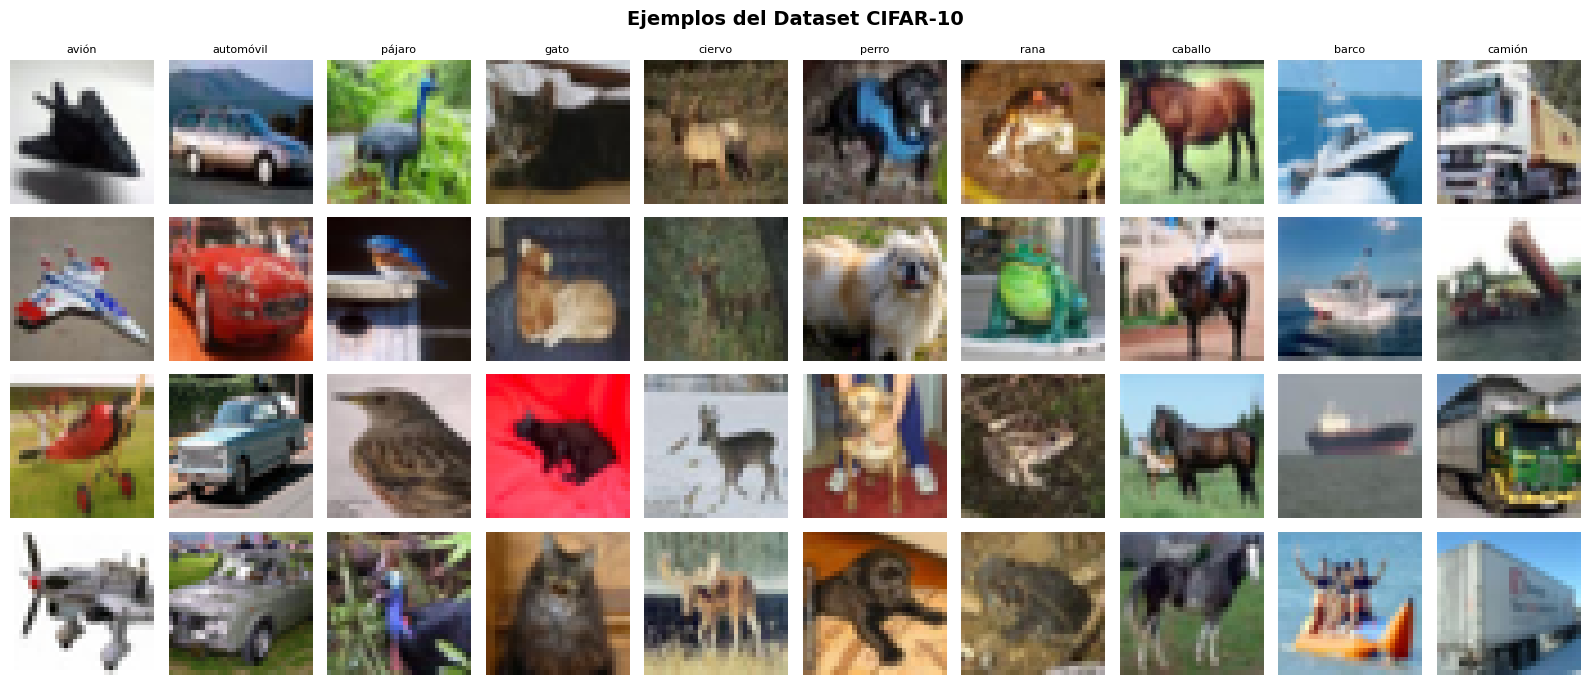

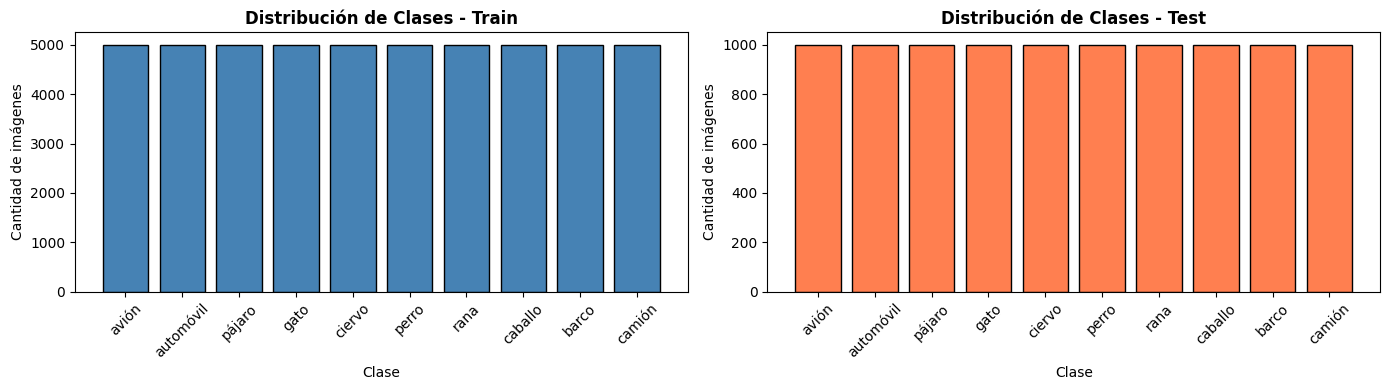

In [9]:
# Visualización de ejemplos del dataset
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
fig.suptitle('Ejemplos del Dataset CIFAR-10', fontsize=14, fontweight='bold')

for i in range(4):
    for j in range(10):
        idx = np.where(y_train.flatten() == j)[0][i]
        axes[i, j].imshow(X_train[idx])
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(class_names[j], fontsize=8)

plt.tight_layout()
plt.show()

# Distribución de clases
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

unique, counts = np.unique(y_train, return_counts=True)
ax1.bar([class_names[i] for i in unique], counts, color='steelblue', edgecolor='black')
ax1.set_title('Distribución de Clases - Train', fontweight='bold')
ax1.set_xlabel('Clase')
ax1.set_ylabel('Cantidad de imágenes')
ax1.tick_params(axis='x', rotation=45)

unique_t, counts_t = np.unique(y_test, return_counts=True)
ax2.bar([class_names[i] for i in unique_t], counts_t, color='coral', edgecolor='black')
ax2.set_title('Distribución de Clases - Test', fontweight='bold')
ax2.set_xlabel('Clase')
ax2.set_ylabel('Cantidad de imágenes')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Preprocesamiento de Datos

In [10]:
# Normalización de píxeles al rango [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

# Codificación one-hot de las etiquetas
y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test,  num_classes=10)

print('=== Preprocesamiento completado ===')
print(f'X_train normalizado: {X_train_norm.min():.2f} - {X_train_norm.max():.2f}')
print(f'y_train one-hot shape: {y_train_ohe.shape}')

# Data augmentation para el entrenamiento
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train_norm)
print('\nData augmentation configurado correctamente.')

=== Preprocesamiento completado ===
X_train normalizado: 0.00 - 1.00
y_train one-hot shape: (50000, 10)

Data augmentation configurado correctamente.


## 4. Construcción de la CNN

In [11]:
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    """
    Arquitectura CNN con:
    - 3 bloques convolucionales con BatchNorm y MaxPooling
    - Capas densas con Dropout para regularización
    - Activación ReLU y softmax en la salida
    """
    model = models.Sequential([
        # --- Bloque 1 ---
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # --- Bloque 2 ---
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # --- Bloque 3 ---
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # --- Cabeza clasificadora ---
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,196,970 (4.57 MB)

 Trainable params: 1,195,306 (4.56 MB)

 Non-trainable params: 1,664 (6.50 KB)

## 5. Entrenamiento del Modelo

In [12]:
# Callbacks para un entrenamiento eficiente
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Entrenamiento con data augmentation
EPOCHS    = 10  # Reducir a 10 para prueba rápida
BATCH_SIZE = 64

history = model.fit(
    datagen.flow(X_train_norm, y_train_ohe, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train_norm) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test_norm, y_test_ohe),
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Entrenamiento completado!')

Epoch 1/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 437s 546ms/step - accuracy: 0.4057 - loss: 1.7101 - val_accuracy: 0.3715 - val_loss: 1.7999 - learning_rate: 0.0010
Epoch 2/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.5000 - loss: 1.3452 - val_accuracy: 0.3714 - val_loss: 1.7934 - learning_rate: 0.0010
Epoch 3/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 493s 559ms/step - accuracy: 0.5611 - loss: 1.2226 - val_accuracy: 0.5299 - val_loss: 1.4220 - learning_rate: 0.0010
Epoch 4/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.5938 - loss: 1.1804 - val_accuracy: 0.5371 - val_loss: 1.3842 - learning_rate: 0.0010
Epoch 5/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 426s 545ms/step - accuracy: 0.6266 - loss: 1.0560 - val_accuracy: 0.6368 - val_loss: 1.0681 - learning_rate: 0.0010
Epoch 6/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.6719 - loss: 0.9525 - val_accuracy: 0.6360 - val_loss: 1.0473 - learning_rate: 0.0010
Epoch 7/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 424s 543ms/step - accuracy: 0.

## 6. Visualización del Historial de Entrenamiento

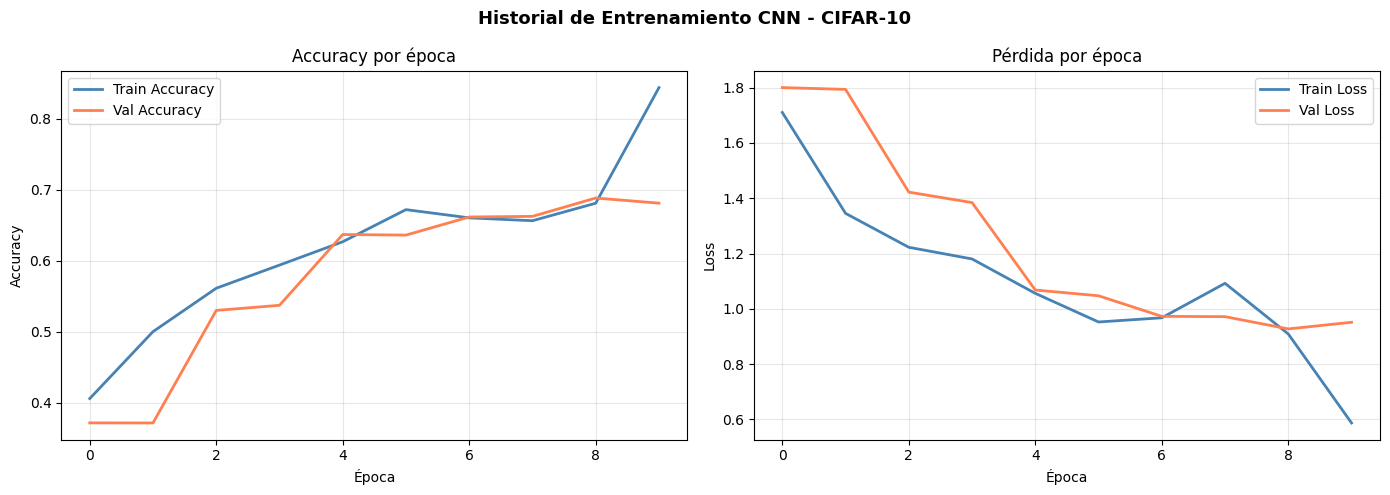

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Historial de Entrenamiento CNN - CIFAR-10', fontsize=13, fontweight='bold')

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='coral',     linewidth=2)
ax1.set_title('Accuracy por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss',   color='coral',     linewidth=2)
ax2.set_title('Pérdida por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluación del Modelo

In [14]:
# Métricas finales
test_loss, test_acc = model.evaluate(X_test_norm, y_test_ohe, verbose=0)
print(f'=== Resultados en Test ===')
print(f'Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Loss:     {test_loss:.4f}')

# Predicciones
y_pred_proba = model.predict(X_test_norm, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = y_test.flatten()

# Reporte de clasificación
print('\n=== Reporte de Clasificación ===')
print(classification_report(y_true, y_pred, target_names=class_names))

=== Resultados en Test ===
Accuracy: 0.6882 (68.82%)
Loss:     0.9274

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

       avión       0.81      0.67      0.73      1000
   automóvil       0.90      0.85      0.87      1000
      pájaro       0.73      0.49      0.59      1000
        gato       0.64      0.32      0.42      1000
      ciervo       0.55      0.74      0.63      1000
       perro       0.90      0.34      0.49      1000
        rana       0.54      0.93      0.69      1000
     caballo       0.79      0.71      0.75      1000
       barco       0.65      0.92      0.76      1000
      camión       0.70      0.92      0.80      1000

    accuracy                           0.69     10000
   macro avg       0.72      0.69      0.67     10000
weighted avg       0.72      0.69      0.67     10000



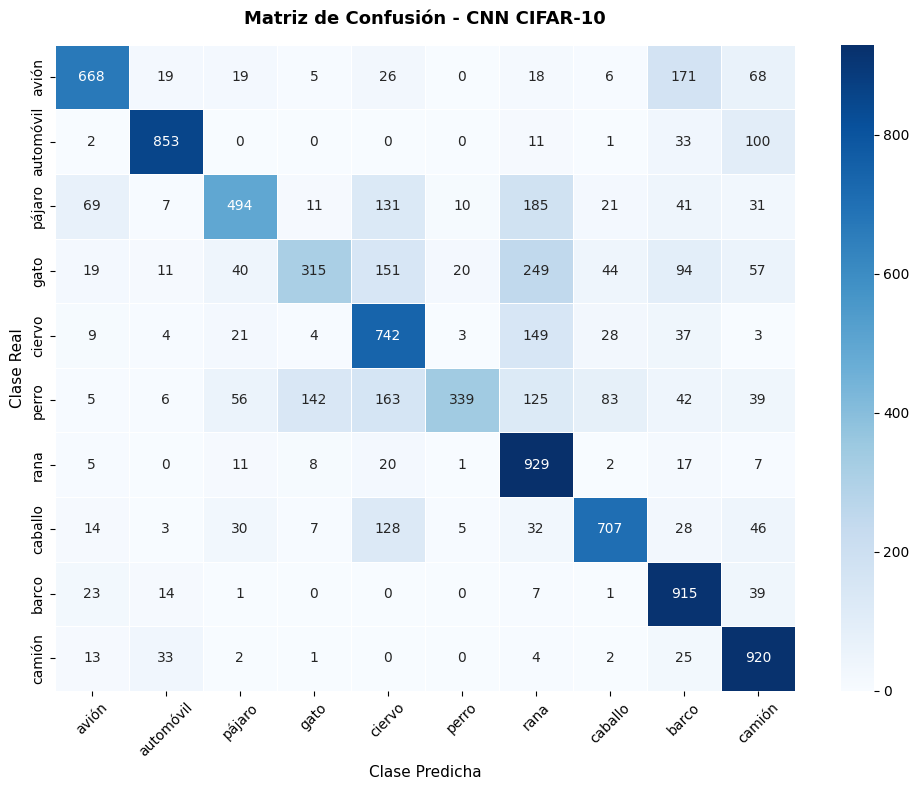

In [15]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_title('Matriz de Confusión - CNN CIFAR-10', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Clase Real', fontsize=11)
ax.set_xlabel('Clase Predicha', fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

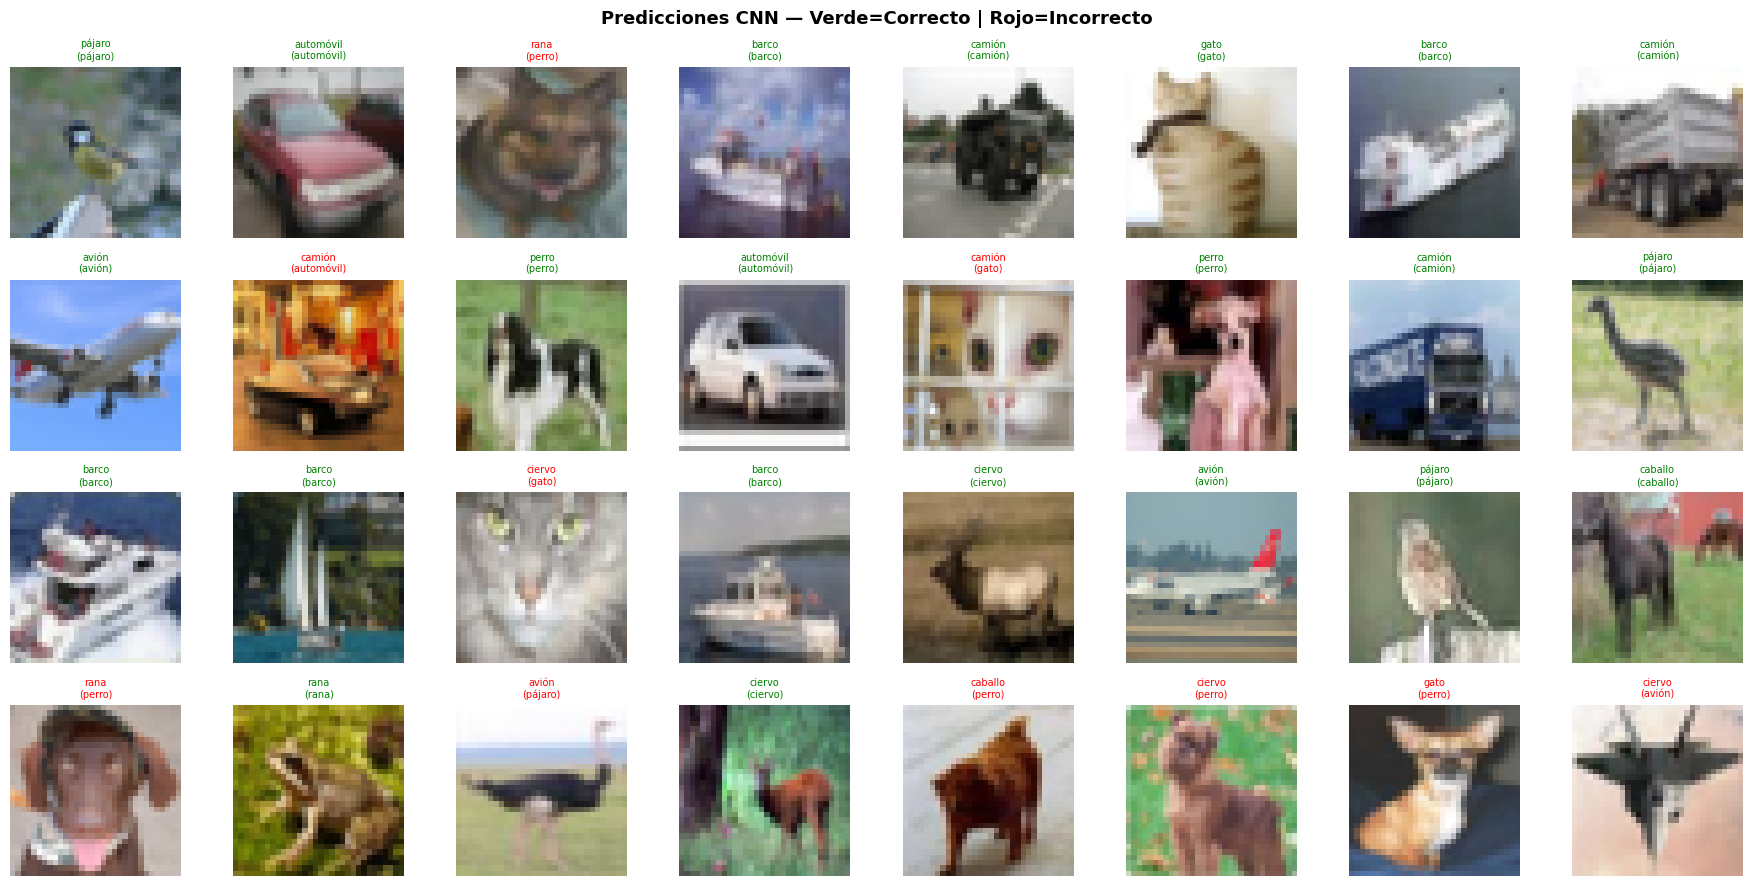

In [16]:
# Visualización de predicciones: aciertos y errores
fig, axes = plt.subplots(4, 8, figsize=(18, 9))
fig.suptitle('Predicciones CNN — Verde=Correcto | Rojo=Incorrecto', fontsize=13, fontweight='bold')

np.random.seed(42)
indices = np.random.choice(len(X_test), 32, replace=False)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_test[idx])
    ax.axis('off')
    pred  = class_names[y_pred[idx]]
    true  = class_names[y_true[idx]]
    color = 'green' if y_pred[idx] == y_true[idx] else 'red'
    ax.set_title(f'{pred}\n({true})', color=color, fontsize=7)

plt.tight_layout()
plt.savefig('cnn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Visualización de Filtros de la Primera Capa Conv

Los filtros aprendidos por la primera capa convolucional muestran qué patrones visuales detecta la CNN.

Forma de los filtros: (3, 3, 3, 32)


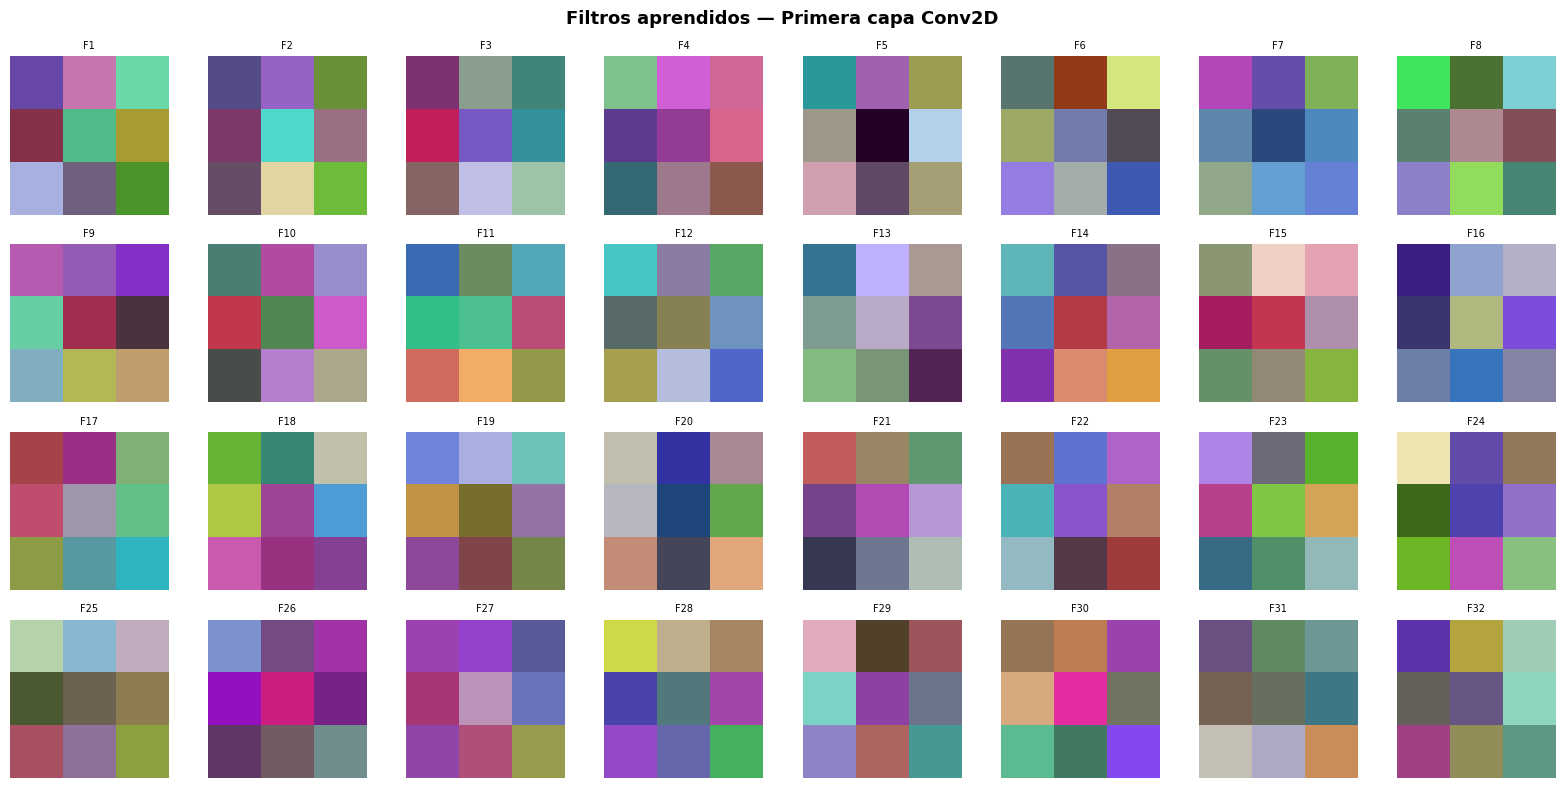


✅ Notebook CNN completado exitosamente!
Accuracy final en test: 68.82%


In [17]:
# Extraer pesos de la primera capa Conv2D
filters, biases = model.layers[0].get_weights()
print(f'Forma de los filtros: {filters.shape}')  # (3, 3, 3, 32)

# Normalizar los filtros para visualizarlos
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Filtros aprendidos — Primera capa Conv2D', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(filters_norm[:, :, :, i])
    ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('cnn_filters.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Notebook CNN completado exitosamente!')
print(f'Accuracy final en test: {test_acc*100:.2f}%')